# Plots

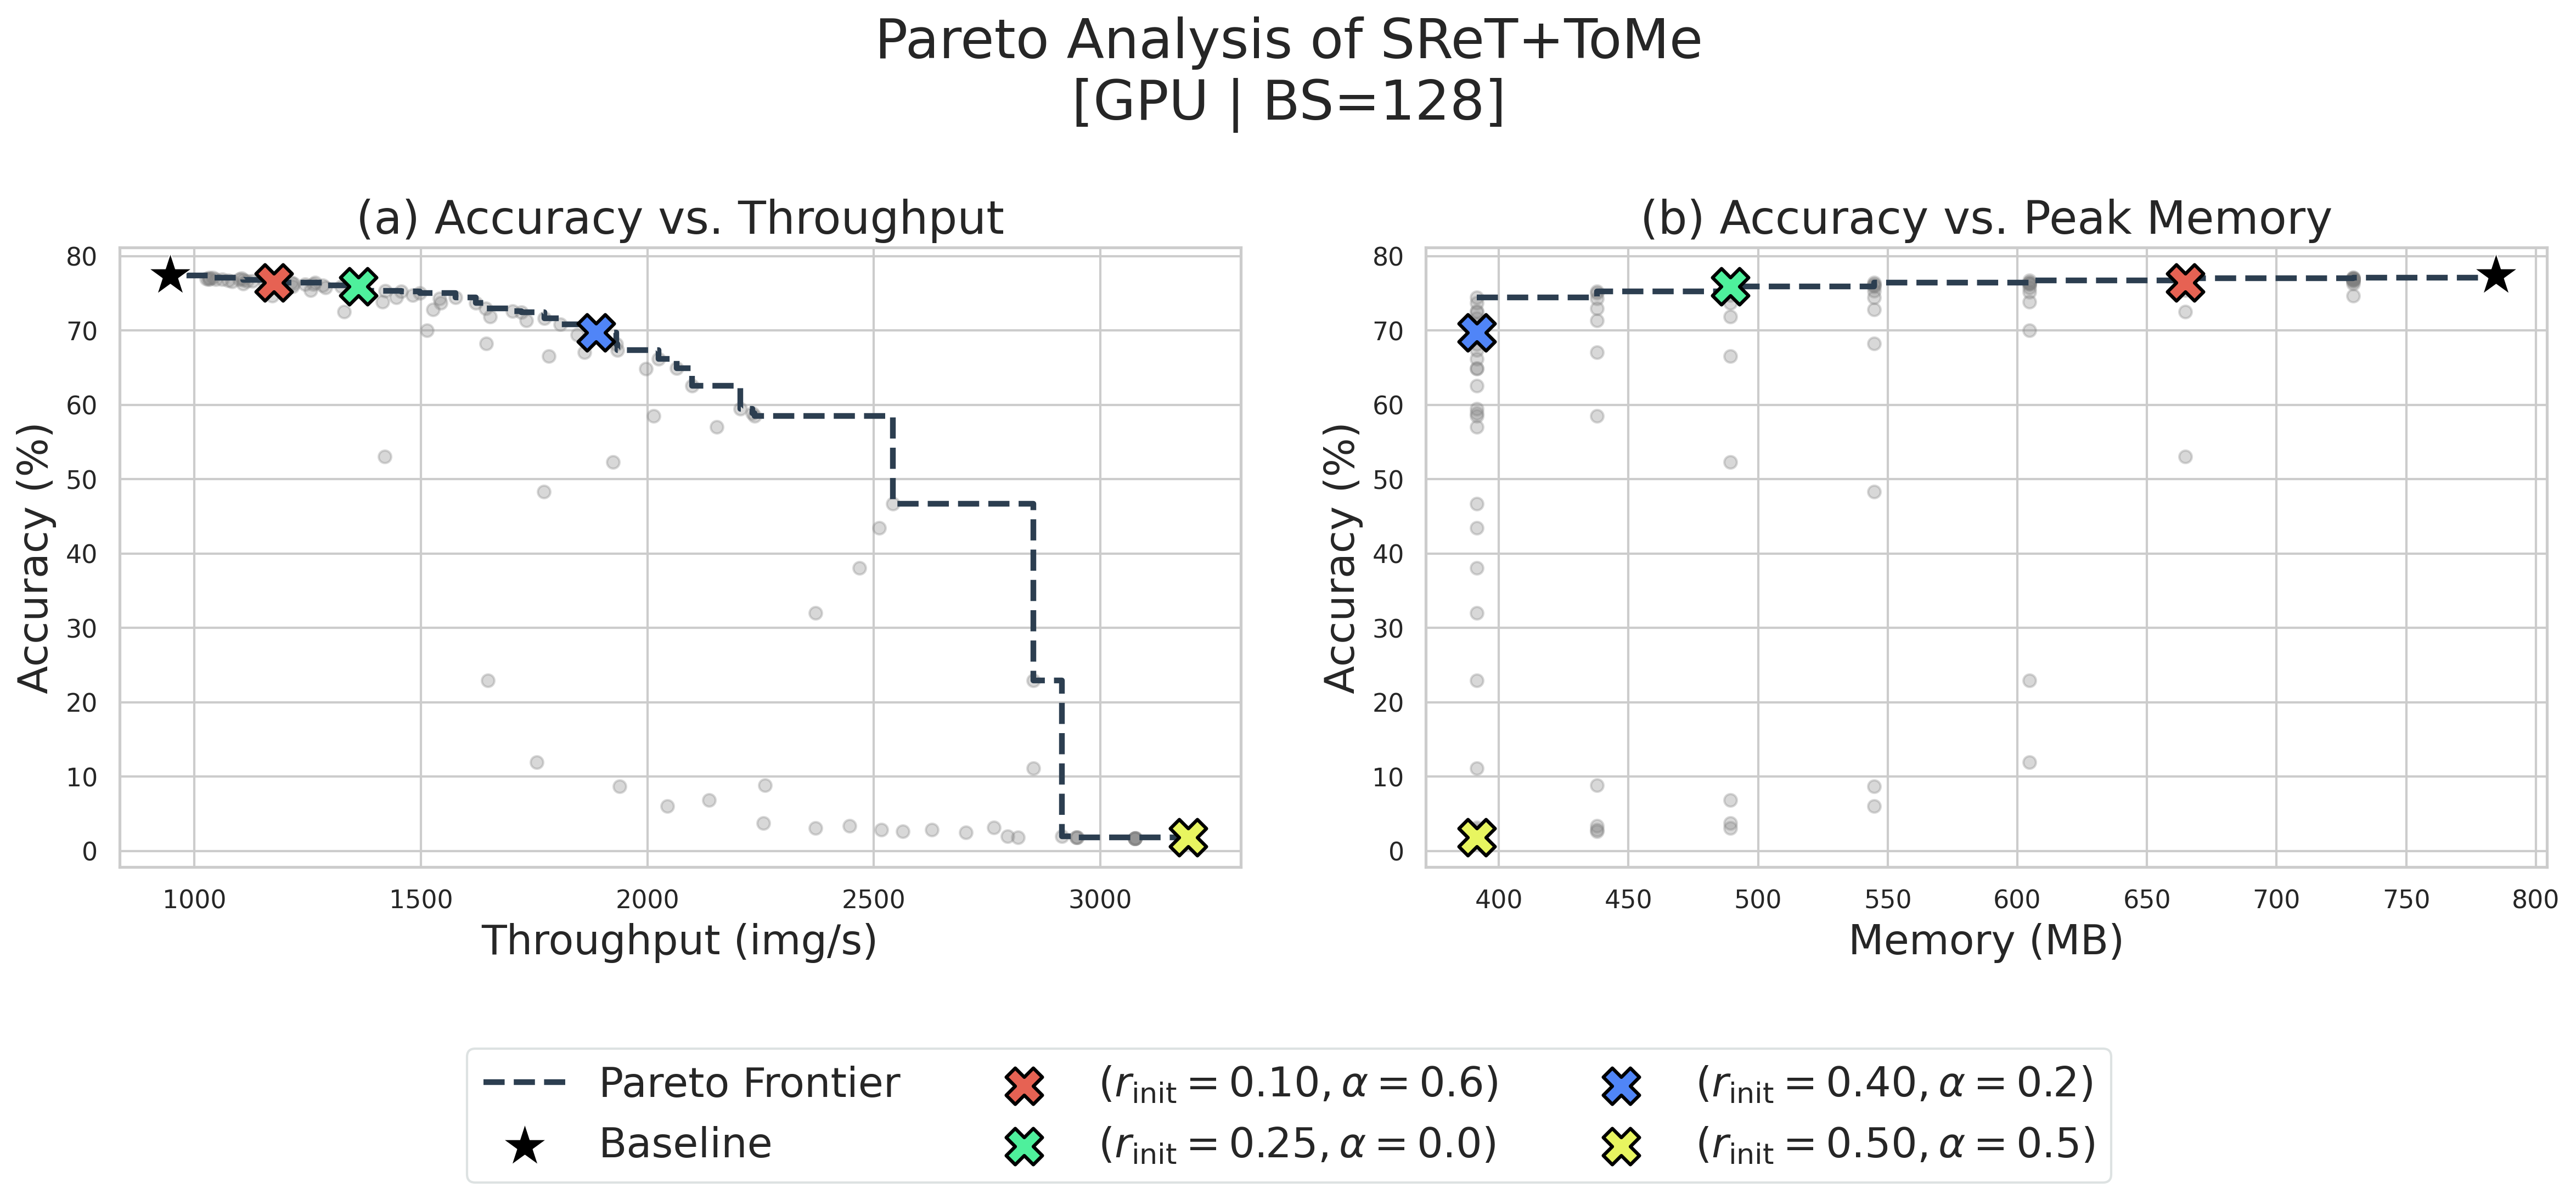

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_pareto_frontier(Xs, Ys, maxX=True, maxY=True):
    """
    Calculates the Pareto optimal coordinates for plotting.
    """
    points = list(zip(Xs, Ys))
    # sort based on x-value or y-value
    points.sort(key=lambda p: (-p[0] if maxX else p[0], -p[1] if maxY else p[1]))
    
    # sweep the frontier
    pareto_front = [points[0]]
    for point in points[1:]:
        if maxY:
            if point[1] > pareto_front[-1][1]:
                pareto_front.append(point)
        else:
            if point[1] < pareto_front[-1][1]:
                pareto_front.append(point)
    
    # return as unzipped lists
    return [p[0] for p in pareto_front], [p[1] for p in pareto_front]

# load data
df_cpu = pd.read_csv('grid_search_cpu.csv')
df_gpu = pd.read_csv('grid_search_gpu.csv')

# remove 'failed' rows
df_cpu = df_cpu.replace('FAILED', pd.NA).dropna()
df_gpu = df_gpu.replace('FAILED', pd.NA).dropna()

# convert to numeric
df_cpu = df_cpu.apply(pd.to_numeric)
df_gpu = df_gpu.apply(pd.to_numeric)

# merge datasets
merged = pd.merge(df_cpu, df_gpu, on=['initial_r', 'alpha'])

baseline = merged[(merged['initial_r'] == 0.0) & (merged['alpha'] == 1.0)]

targets = [
    {'name': r'($r_{\text{init}}=0.10, \alpha=0.6$)', 'r': 0.10, 'a': 0.6, 'color': "#e66253", 'marker': 'X'},
    {'name': r'($r_{\text{init}}=0.25, \alpha=0.0$)', 'r': 0.25, 'a': 0.0, 'color': "#4ef09c", 'marker': 'X'},
    {'name': r'($r_{\text{init}}=0.40, \alpha=0.2$)', 'r': 0.40, 'a': 0.2, 'color': "#5085f7", 'marker': 'X'},
    {'name': r'($r_{\text{init}}=0.50, \alpha=0.5$)', 'r': 0.50, 'a': 0.5, 'color': "#e8f560", 'marker': 'X'},
]

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 18,            
    'axes.labelsize': 18,       
    'axes.titlesize': 20,       
    'legend.fontsize': 16,      
    'figure.dpi': 300,
    'lines.linewidth': 2.5      
})

fig, axs = plt.subplots(1, 2, figsize=(16, 7))

plot_configs = [
    {
        'ax': axs[0], 
        'x_col': 'throughput_bs128', 
        'title': '(a) Accuracy vs. Throughput', 
        'xlabel': 'Throughput (img/s)', 
        'maxX': True
    },
    {
        'ax': axs[1], 
        'x_col': 'activation_mem_bs128', 
        'title': '(b) Accuracy vs. Peak Memory', 
        'xlabel': 'Memory (MB)', 
        'maxX': False
    },
]

for cfg in plot_configs:
    ax = cfg['ax']
    Xs, Ys = merged[cfg['x_col']].values, merged['accuracy'].values
    pX, pY = get_pareto_frontier(Xs, Ys, maxX=cfg['maxX'], maxY=True)
    
    ax.scatter(Xs, Ys, color='gray', alpha=0.3, s=30, zorder=1)
    
    ax.step(pX, pY, where='pre' if cfg['maxX'] else 'post', color='#2c3e50', linestyle='--', zorder=2, label='Pareto Frontier')
    
    ax.scatter(baseline[cfg['x_col']], baseline['accuracy'], color='black', marker='*', s=400, edgecolors='white', linewidths=0.5, label='Baseline', zorder=5)

    for t in targets:
        row = merged[(merged['initial_r'] == t['r']) & (merged['alpha'] == t['a'])]
        if not row.empty:
            ax.scatter(row.iloc[0][cfg['x_col']], row.iloc[0]['accuracy'], marker=t['marker'], color=t['color'], s=250, edgecolors='black', linewidths=1.5, zorder=10, label=t['name'])

    ax.set_title(cfg['title'])
    ax.set_xlabel(cfg['xlabel'])
    ax.set_ylabel('Accuracy (%)')

handles, labels = axs[0].get_legend_handles_labels()
unique_dict = dict(zip(labels, handles))
unique_handles = list(unique_dict.values())
unique_labels = list(unique_dict.keys())

fig.legend(unique_handles, unique_labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=18, frameon=True, facecolor='white', edgecolor='#d5dbdb')
fig.suptitle('Pareto Analysis of SReT+ToMe\n[GPU | BS=128]', fontsize=24)
fig.tight_layout(rect=[0, 0.12, 1, 1], w_pad=2.0)
fig.savefig('plots/pareto_frontier.pdf', bbox_inches='tight')
fig.savefig('plots/pareto_frontier.png', bbox_inches='tight')
plt.show()
plt.close(fig)

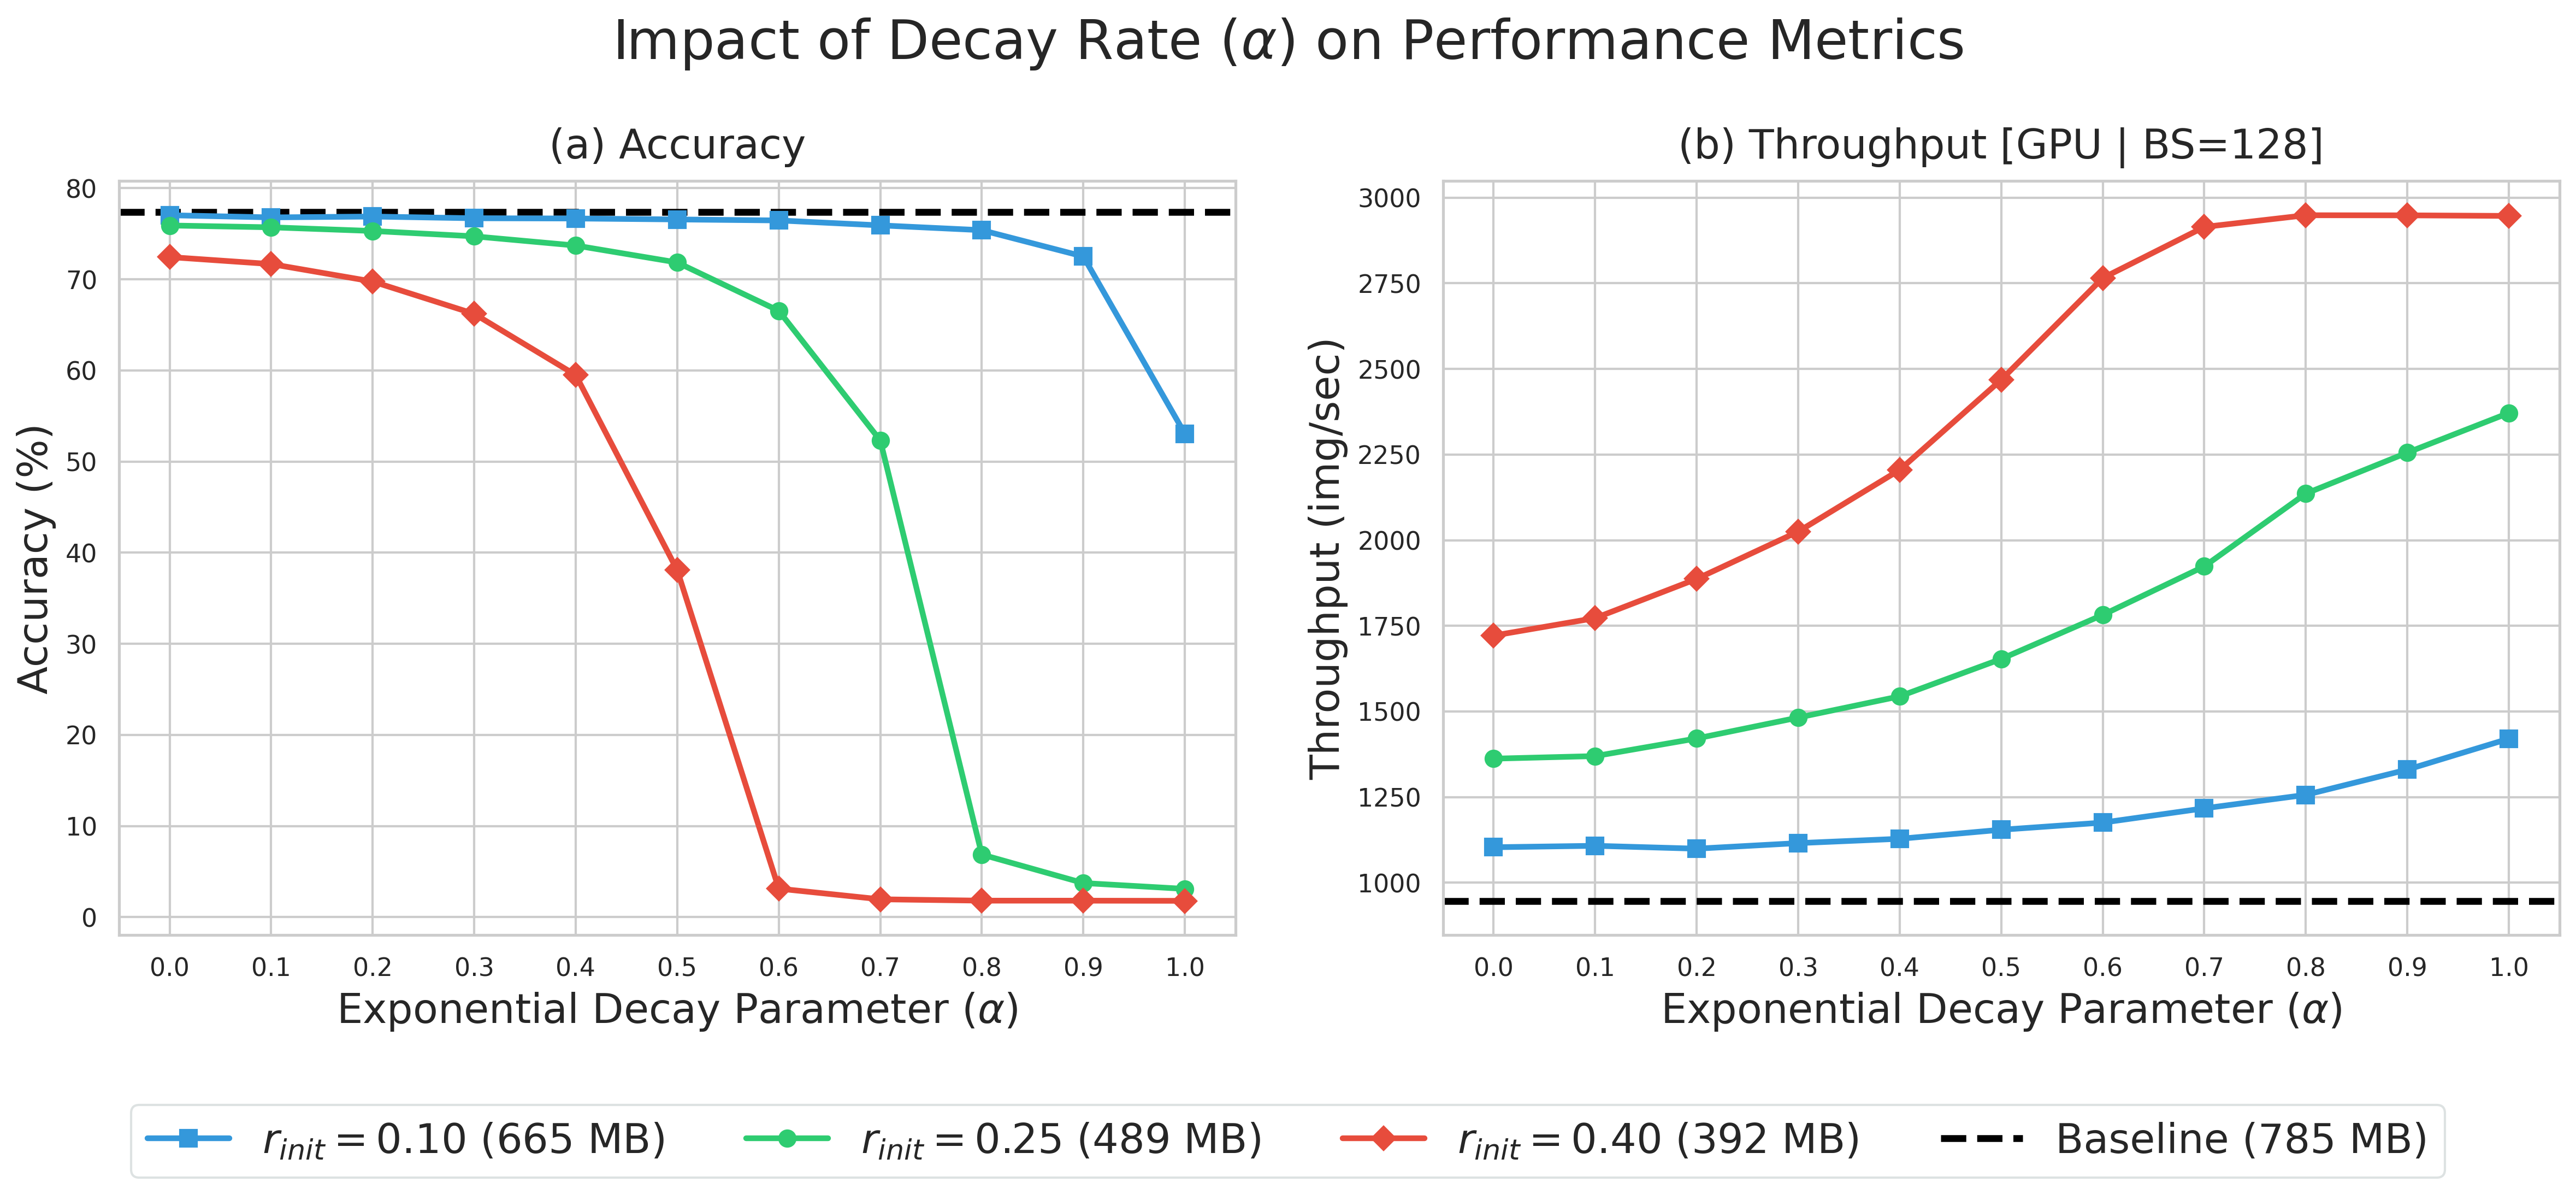

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 16,            
    'axes.labelsize': 18,       
    'axes.titlesize': 18,       
    'legend.fontsize': 16,      
    'figure.dpi': 300,
    'lines.linewidth': 2.5      
})

df_gpu = pd.read_csv('grid_search_gpu.csv')
df_cpu = pd.read_csv('grid_search_cpu.csv')

df_merged = pd.merge(df_gpu, df_cpu, on=['initial_r', 'alpha'], suffixes=('_gpu', '_cpu'))

metrics = ['accuracy', 'throughput_bs128', 'throughput', 'activation_mem_bs128']
for col in metrics:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

baseline = df_merged[(df_merged['initial_r'] == 0.0) & (df_merged['alpha'] == 1.0)].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax_acc, ax_gpu_tp = axes[0], axes[1]

r_configs = {
    0.10: {'color': '#3498db', 'marker': 's', 'label': '$r_{init}=0.10$'},
    0.25: {'color': '#2ecc71', 'marker': 'o', 'label': '$r_{init}=0.25$'},
    0.40: {'color': '#e74c3c', 'marker': 'D', 'label': '$r_{init}=0.40$'}
}

alphas = np.arange(0.0, 1.1, 0.1)

for r_val, cfg in r_configs.items():
    subset = df_merged[np.isclose(df_merged['initial_r'], r_val)].sort_values('alpha')
    x = subset['alpha']
    
    static_pam = subset['activation_mem_bs128'].iloc[0]
    legend_label = f"{cfg['label']} ({static_pam:.0f} MB)"

    ax_acc.plot(x, subset['accuracy'], color=cfg['color'], marker=cfg['marker'], markersize=7, label=legend_label, zorder=3)
    ax_gpu_tp.plot(x, subset['throughput_bs128'], color=cfg['color'], marker=cfg['marker'], markersize=7, zorder=3)

def format_ax(ax, title, ylabel, baseline_val, baseline_label='Baseline', show_baseline=True):
    ax.set_title(title, pad=10)
    ax.set_xlabel(r'Exponential Decay Parameter ($\alpha$)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(alphas)
    ax.set_xlim(-0.05, 1.05)
    if show_baseline:
        ax.axhline(baseline_val, color='black', linestyle='--', linewidth=3, zorder=1, label=baseline_label)

base_pam = baseline['activation_mem_bs128']
base_label = f"Baseline ({base_pam:.0f} MB)"

format_ax(ax_acc, '(a) Accuracy', 'Accuracy (%)', baseline['accuracy'], base_label)
format_ax(ax_gpu_tp, '(b) Throughput [GPU | BS=128]', 'Throughput (img/sec)', baseline['throughput_bs128'], base_label)

handles, labels = ax_acc.get_legend_handles_labels()

fig.suptitle(r'Impact of Decay Rate ($\alpha$) on Performance Metrics', fontsize=24)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=True, facecolor='white', edgecolor='#d5dbdb', fontsize=18)
fig.tight_layout(rect=[0, 0.06, 1, 1], w_pad=2.0)
fig.savefig('plots/decay_effect.pdf', bbox_inches='tight')
fig.savefig('plots/decay_effect.png', bbox_inches='tight')
plt.show()
plt.close(fig)

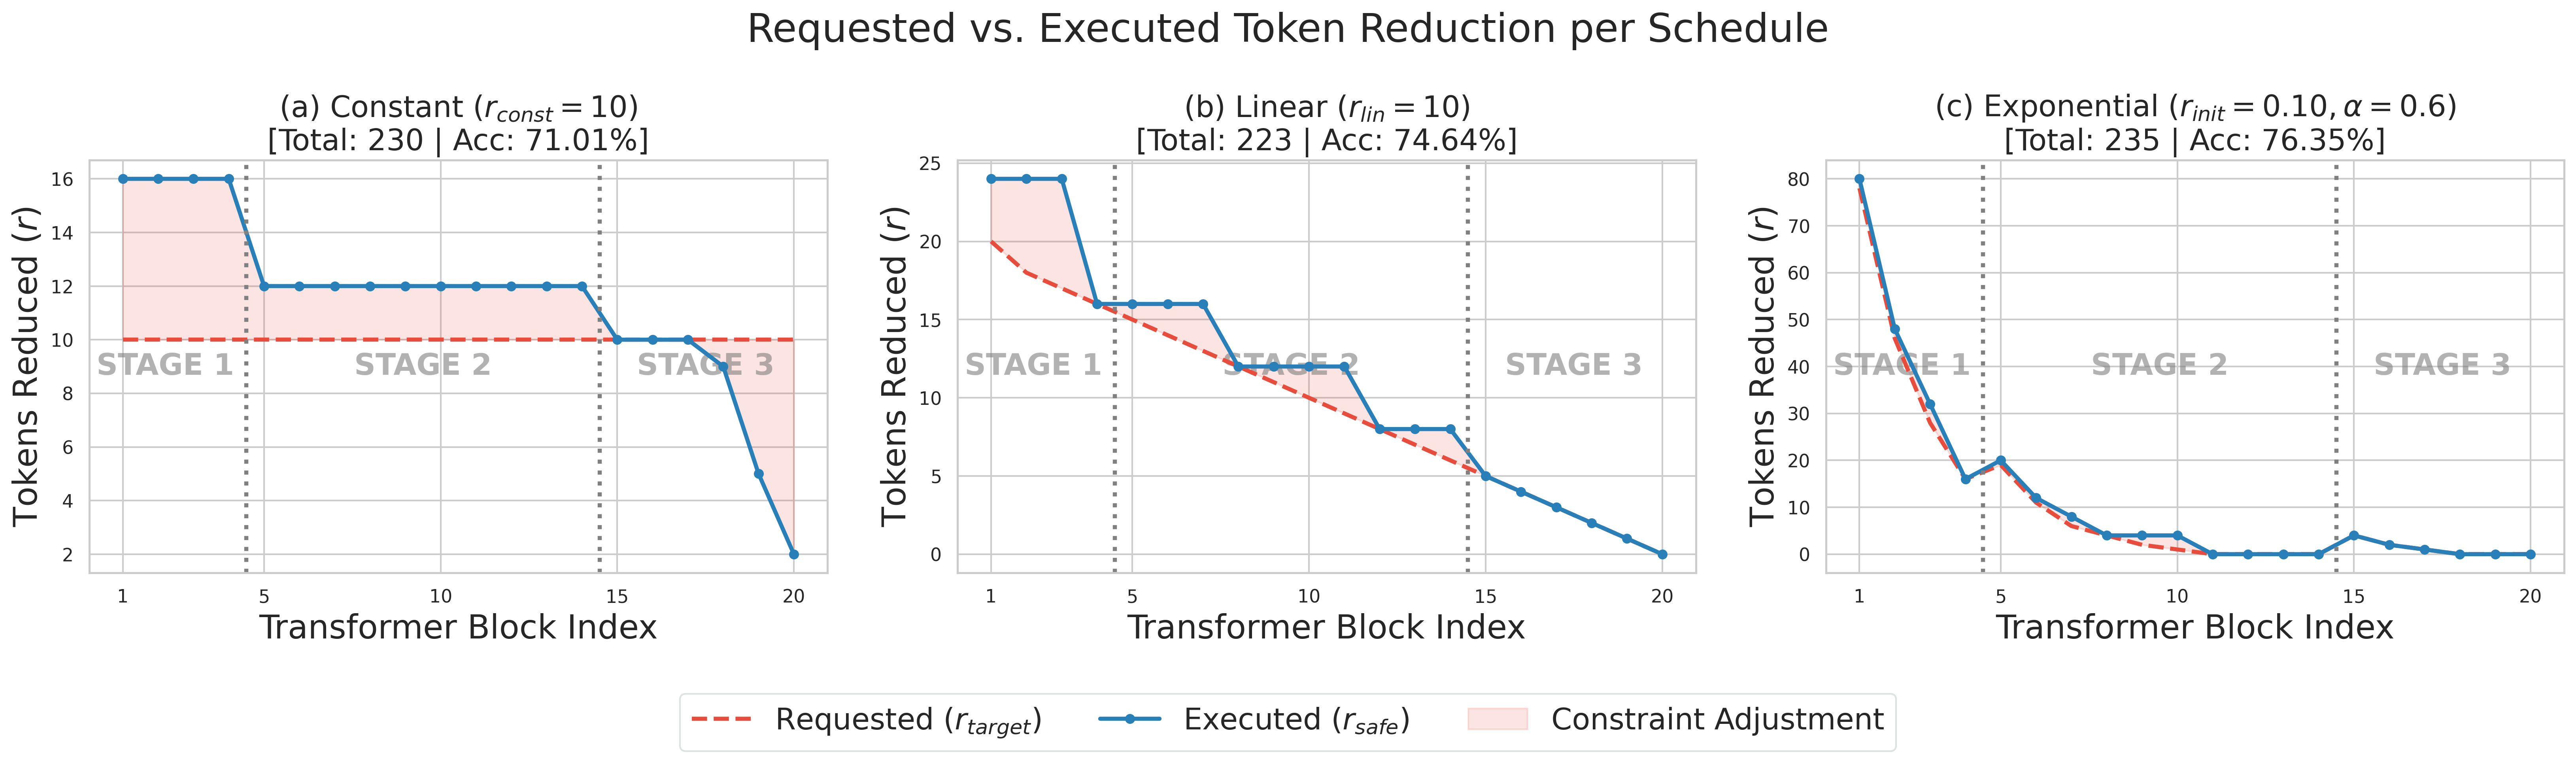

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 16,            
    'axes.labelsize': 20,       
    'axes.titlesize': 20,       
    'legend.fontsize': 18,      
    'figure.dpi': 300,
    'lines.linewidth': 2.5      
})

x_blocks = np.arange(1, 21)

# constant r=10
c_target = np.array([10]*4 + [10]*10 + [10]*6)
c_actual = np.array([16, 16, 16, 16] + [12, 12, 12, 12, 12, 12, 12, 12, 12, 12] + [10, 10, 10, 9, 5, 2])

# linear r=10
l_target = np.array([20, 18, 17, 16] + [15, 14, 13, 12, 11, 10, 9, 8, 7, 6] + [5, 4, 3, 2, 1, 0])
l_actual = np.array([24, 24, 24, 16] + [16, 16, 16, 12, 12, 12, 12, 8, 8, 8] + [5, 4, 3, 2, 1, 0])

# exp r-init=0.10 alpha=0.6
e6_target = np.array([78, 46, 28, 16] + [19, 11, 6, 4, 2, 1, 0, 0, 0, 0] + [4, 2, 1, 0, 0, 0])
e6_actual = np.array([80, 48, 32, 16] + [20, 12, 8, 4, 4, 4, 0, 0, 0, 0] + [4, 2, 1, 0, 0, 0])


fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharex=True)

schedules = [
    ("(a) Constant ($r_{const}=10$)\n[Total: 230 | Acc: 71.01%]", c_target, c_actual),
    ("(b) Linear ($r_{lin}=10$)\n[Total: 223 | Acc: 74.64%]", l_target, l_actual),
    ("(c) Exponential ($r_{init}=0.10, \\alpha=0.6$)\n[Total: 235 | Acc: 76.35%]", e6_target, e6_actual),
]

for ax, (title, target, actual) in zip(axes, schedules):
    ax.plot(x_blocks, target, color='#e74c3c', linestyle='--', label='Requested ($r_{target}$)')
    ax.plot(x_blocks, actual, color='#2980b9', linestyle='-', marker='o', markersize=5, label='Executed ($r_{safe}$)')
    ax.fill_between(x_blocks, target, actual, color='#e74c3c', alpha=0.15, label='Constraint Adjustment')
    
    ax.axvline(x=4.5, color='gray', linestyle=':')
    ax.axvline(x=14.5, color='gray', linestyle=':')

    trans = ax.get_xaxis_transform()
    ax.text(2.2, 0.5, 'STAGE 1', ha='center', va='center', transform=trans, fontsize=18, fontweight='bold', color='gray', alpha=0.6, zorder=1)
    ax.text(9.5, 0.5, 'STAGE 2', ha='center', va='center', transform=trans, fontsize=18, fontweight='bold', color='gray', alpha=0.6, zorder=1)
    ax.text(17.5, 0.5, 'STAGE 3', ha='center', va='center', transform=trans, fontsize=18, fontweight='bold', color='gray', alpha=0.6, zorder=1)
    
    ax.set_title(title, fontsize=18)
    ax.set_xticks([1, 5, 10, 15, 20])
    
    ax.set_xlabel('Transformer Block Index')
    ax.set_ylabel('Tokens Reduced ($r$)')

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=True, facecolor='white', edgecolor='#d5dbdb')
fig.suptitle('Requested vs. Executed Token Reduction per Schedule', fontsize=24)
fig.tight_layout(rect=[0, 0.05, 1, 1], w_pad=2.0)
fig.savefig('plots/reduction.pdf', bbox_inches='tight')
fig.savefig('plots/reduction.png', bbox_inches='tight')
plt.show()
plt.close(fig)